# 🎵 Spotify Tracks Dataset — EDA & Preprocessing

Questo notebook illustra un flusso completo di **Exploratory Data Analysis (EDA)** e **preprocessing** sul dataset Spotify Tracks.

### Struttura del notebook
1. Setup & caricamento dati
2. Ispezione iniziale
3. Analisi valori mancanti
4. Analisi distribuzione features numeriche
5. Analisi features categoriche
6. Analisi correlazioni
7. Rilevamento outlier
8. Preprocessing
9. Dataset finale

---
## 1. Setup & Caricamento Dati

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Impostazioni visualizzazione
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Librerie importate correttamente')

Librerie importate correttamente


In [6]:
# Download dataset
DATASET_ID = "yashdev01/spotify-tracks-dataset"
FILE_NAME  = "spotify-tracks-dataset.csv"
OUTPUT_DIR = os.path.join(os.getcwd(), "data", "spotify") # "/cartella/del/notebook/data/spotify"

kagglehub.dataset_download(DATASET_ID, output_dir=OUTPUT_DIR)

df = pd.read_csv(os.path.join(OUTPUT_DIR, FILE_NAME)) 

print(f'Dataset caricato: {df.shape[0]:,} righe × {df.shape[1]} colonne')

100%|██████████| 8.42M/8.42M [00:02<00:00, 3.91MB/s]

Extracting files...


Dataset caricato: 114,000 righe × 22 colonne


---
## 2. Ispezione Iniziale

In [62]:
# Prime 10 righe
df.head(10)

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic
5,5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.481,6,-8.807,1,0.105,0.289,0.000,0.189,0.666,98.017,4,acoustic
6,6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.147,2,-8.822,1,0.035,0.857,0.000,0.091,0.076,141.284,3,acoustic
7,7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.444,11,-9.331,1,0.042,0.559,0.000,0.097,0.712,150.960,4,acoustic
8,8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.414,0,-8.700,1,0.037,0.294,0.000,0.151,0.669,130.088,4,acoustic
9,9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.632,1,-6.770,1,0.029,0.426,0.004,0.073,0.196,78.899,4,acoustic


In [68]:
df = df.drop(columns=[col for col in df.columns if 'Unnamed' in col])
# Oppure
# unnamed_cols = []
# for col in df.columns:
#     if 'Unnamed' in col:
#         unnamed_cols.append(col)

# df = df.drop(columns=unnamed_cols)

In [ ]:
# Info generali: tipi, memoria, conteggio not-null
df.info()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic


## Statistiche descrittive

`describe()` restituisce un riepilogo statistico di tutte le colonne numeriche del DataFrame: conteggio, media, deviazione standard, minimo, massimo e percentili.

### Opzioni di visualizzazione
```python
df.describe()    # vista standard
df.describe().T  # trasposta — colonne come righe, più leggibile con molte colonne
```

### Stilizzare l'output

Pandas permette di aggiungere formattazione visiva al DataFrame con `.style`:
```python
df.describe().T.style \
    .background_gradient(cmap='Blues', subset=['mean', 'std']) \
    .highlight_min('mean', color='lightcoral')
```

- `.background_gradient(cmap='Blues', subset=['mean', 'std'])` — applica un gradiente di colore blu sulle colonne `mean` e `std`: valori più alti appaiono più scuri
- `.highlight_min('mean', color='lightcoral')` — evidenzia in rosso chiaro il valore minimo nella colonna `mean`
- `\` — permette di spezzare il codice su più righe per renderlo più leggibile


In [15]:
# Statistiche descrittive — colonne numeriche
print('=== NUMERICHE ===')
df.describe().T.style \
    .background_gradient(cmap='Blues', subset=['mean', 'std']) \
    .highlight_min('mean', color='lightcoral') 
    

=== NUMERICHE ===


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,114000.000000,56999.500000,32909.109681,0.000000,28499.750000,56999.500000,85499.250000,113999.000000
Unnamed: 0,114000.000000,56999.500000,32909.109681,0.000000,28499.750000,56999.500000,85499.250000,113999.000000
popularity,114000.000000,33.238535,22.305078,0.000000,17.000000,35.000000,50.000000,100.000000
duration_ms,114000.000000,228029.153114,107297.712645,0.000000,174066.000000,212906.000000,261506.000000,5237295.000000
danceability,114000.000000,0.566800,0.173542,0.000000,0.456000,0.580000,0.695000,0.985000
energy,114000.000000,0.641383,0.251529,0.000000,0.472000,0.685000,0.854000,1.000000
key,114000.000000,5.309140,3.559987,0.000000,2.000000,5.000000,8.000000,11.000000
loudness,114000.000000,-8.258960,5.029337,-49.531000,-10.013000,-7.004000,-5.003000,4.532000
mode,114000.000000,0.637553,0.480709,0.000000,0.000000,1.000000,1.000000,1.000000
speechiness,114000.000000,0.084652,0.105732,0.000000,0.035900,0.048900,0.084500,0.965000


In [37]:
# Statistiche descrittive — colonne categoriche
print('=== CATEGORICHE ===')
df.describe(include=['object', 'string'])

=== CATEGORICHE ===


,track_id,artists,album_name,track_name,track_genre
count,114000,113999,113999,113999,114000
unique,89741,31437,46589,73608,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,9,279,195,151,1000


# 3. Valori mancanti

Prima di analizzare un dataset è fondamentale identificare i valori mancanti, 
che potrebbero influenzare i risultati dell'analisi.

### Costruire la tabella riassuntiva
```python
missing = pd.DataFrame({
    'count': df.isnull().sum(),       # numero di valori nulli per colonna
    'percent': df.isnull().mean() * 100  # percentuale di valori nulli
})
```

- `df.isnull().sum()` — conta i valori nulli per ogni colonna
- `df.isnull().mean() * 100` — calcola la percentuale di nulli (media di True/False × 100)

### Filtrare e ordinare
```python
.query('count > 0')                    # tiene solo le colonne con almeno un nullo
.sort_values('percent', ascending=False)  # ordina dal più mancante al meno
```

- `.query()` — filtra le righe in base a una condizione, come alternativa a `df[df["count"] > 0]`

### Gestire il caso senza valori mancanti
```python
if missing.empty:
    print('Nessun valore mancante nel dataset!')
else:
    print(f'{len(missing)} colonne con valori mancanti:')
    display(missing.style.bar(subset=['percent'], color='#d65f5f'))
```

- `missing.empty` — restituisce `True` se il DataFrame non ha righe
- `len(missing)` — numero di colonne con valori mancanti
- `.style.bar()` — aggiunge una barra proporzionale alla percentuale dentro la cella, colorata in rosso



In [38]:
# Tabella riassuntiva valori mancanti
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': df.isnull().mean() * 100
}).query('count > 0').sort_values('percent', ascending=False)

if missing.empty:
    print('Nessun valore mancante nel dataset!')
else:
    print(f'{len(missing)} colonne con valori mancanti:')
    display(missing.style.bar(subset=['percent'], color='#d65f5f'))

3 colonne con valori mancanti:


,count,percent
artists,1,0.000877
album_name,1,0.000877
track_name,1,0.000877


## Heatmap valori mancanti

Per visualizzare *dove* si trovano i valori mancanti nel dataset usiamo una heatmap.
Lavorare sull'intero dataset può essere lento, quindi campionamo 500 righe casuali per mantenere la visualizzazione leggibile.

### Campionare il dataset
```python
sample = df[missing.index].sample(min(500, len(df)), random_state=42)
```

- `missing.index` — seleziona solo le colonne che hanno valori mancanti
- `.sample(min(500, len(df)))` — prende 500 righe casuali, o meno se il dataset è più piccolo
- `random_state=42` — fissa il seme casuale per rendere il risultato riproducibile

### Disegnare la heatmap
```python
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False, cmap='viridis')
```

- `sample.isnull()` — converte i valori in `True` (mancante) / `False` (presente)
- `cbar=False` — nasconde la barra laterale dei colori
- `yticklabels=False` — nasconde le etichette delle righe (sarebbero 500 numeri inutili)
- `cmap='viridis'` — palette di colori: **giallo** = valore mancante, **viola** = valore presente

### Perché vedo quasi solo viola?

Un rettangolo quasi interamente viola significa che il dataset ha **pochissimi valori mancanti** rispetto al totale. Il giallo appare solo nelle celle effettivamente nulle — se sono poche, la heatmap sarà dominata dal viola. In questo caso `describe()` e la tabella riassuntiva precedente sono strumenti più informativi.

            count  percent
artists         1    0.001
album_name      1    0.001
track_name      1    0.001


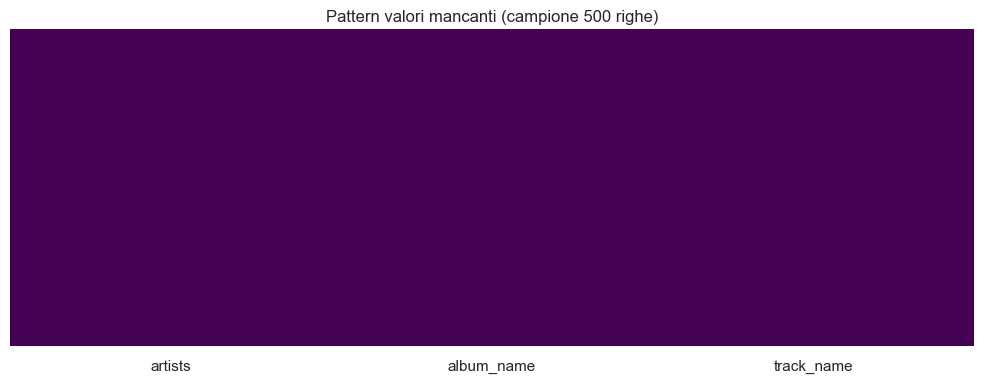

In [39]:
# Heatmap valori mancanti (campione per leggibilità)
print(missing)
if not missing.empty:
    sample = df[missing.index].sample(min(500, len(df)), random_state=42)
    plt.figure(figsize=(10, 4))
    sns.heatmap(sample.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Pattern valori mancanti (campione 500 righe)')
    plt.tight_layout()
    plt.show()

---
## 4. Analisi Distribuzione Features Numeriche

## Selezionare colonne per tipo

Spesso è utile separare le colonne numeriche da quelle testuali per applicare 
operazioni diverse. Pandas permette di farlo con `select_dtypes()`.
```python
df.select_dtypes(include='number')   # seleziona colonne numeriche (int, float)
df.select_dtypes(include='object')   # seleziona colonne testuali
df.select_dtypes(exclude='number')   # esclude le numeriche
```

`.columns.tolist()` converte l'indice delle colonne in una lista Python normale.
```python
df.select_dtypes(include='number').columns.tolist()
# → ['price', 'points', 'unnamed: 0']
```

Il risultato viene poi stampato con una f-string che mostra quante colonne numeriche 
ci sono e i loro nomi.

In [69]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Colonne numeriche ({len(num_cols)}): {num_cols}')

Colonne numeriche (14): ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


## Istogrammi per le features numeriche

Per avere una panoramica rapida di tutte le colonne numeriche, visualizziamo 
i loro istogrammi in una griglia automatica che si adatta al numero di colonne.

### Calcolare il layout della griglia
```python
n     = len(num_cols)            # numero totale di grafici da disegnare
ncols = 3                        # fissiamo 3 colonne per riga
nrows = (n + ncols - 1) // ncols # numero di righe necessarie
```

La formula `(n + ncols - 1) // ncols` calcola la divisione intera arrotondata 
per eccesso. Ad esempio con 7 colonne numeriche:
```python
(7 + 3 - 1) // 3  # → 3 righe invece di 2
```

Senza questo arrotondamento, con 7 grafici e 3 colonne otterremmo 2 righe (6 spazi), 
perdendo l'ultimo grafico.

### Creare la griglia di grafici
```python
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()
```

- `plt.subplots(nrows, ncols)` — crea una griglia di grafici vuoti
- `figsize=(14, nrows * 3)` — l'altezza si adatta automaticamente al numero di righe
- `axes.flatten()` — converte la griglia 2D in una lista 1D per poter accedere 
  ad ogni grafico con un semplice indice `axes[i]`

### Disegnare gli istogrammi
```python
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)
```

- `enumerate()` — restituisce sia l'indice `i` che il nome della colonna `col` ad ogni iterazione
- `dropna()` — esclude i valori nulli prima di disegnare
- `bins=40` — divide i dati in 40 intervalli

### Nascondere i grafici vuoti
```python
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
```

Se il numero di colonne numeriche non è un multiplo esatto di `ncols`, rimangono 
degli spazi vuoti nell'ultima riga. Questo ciclo li nasconde per una visualizzazione pulita.

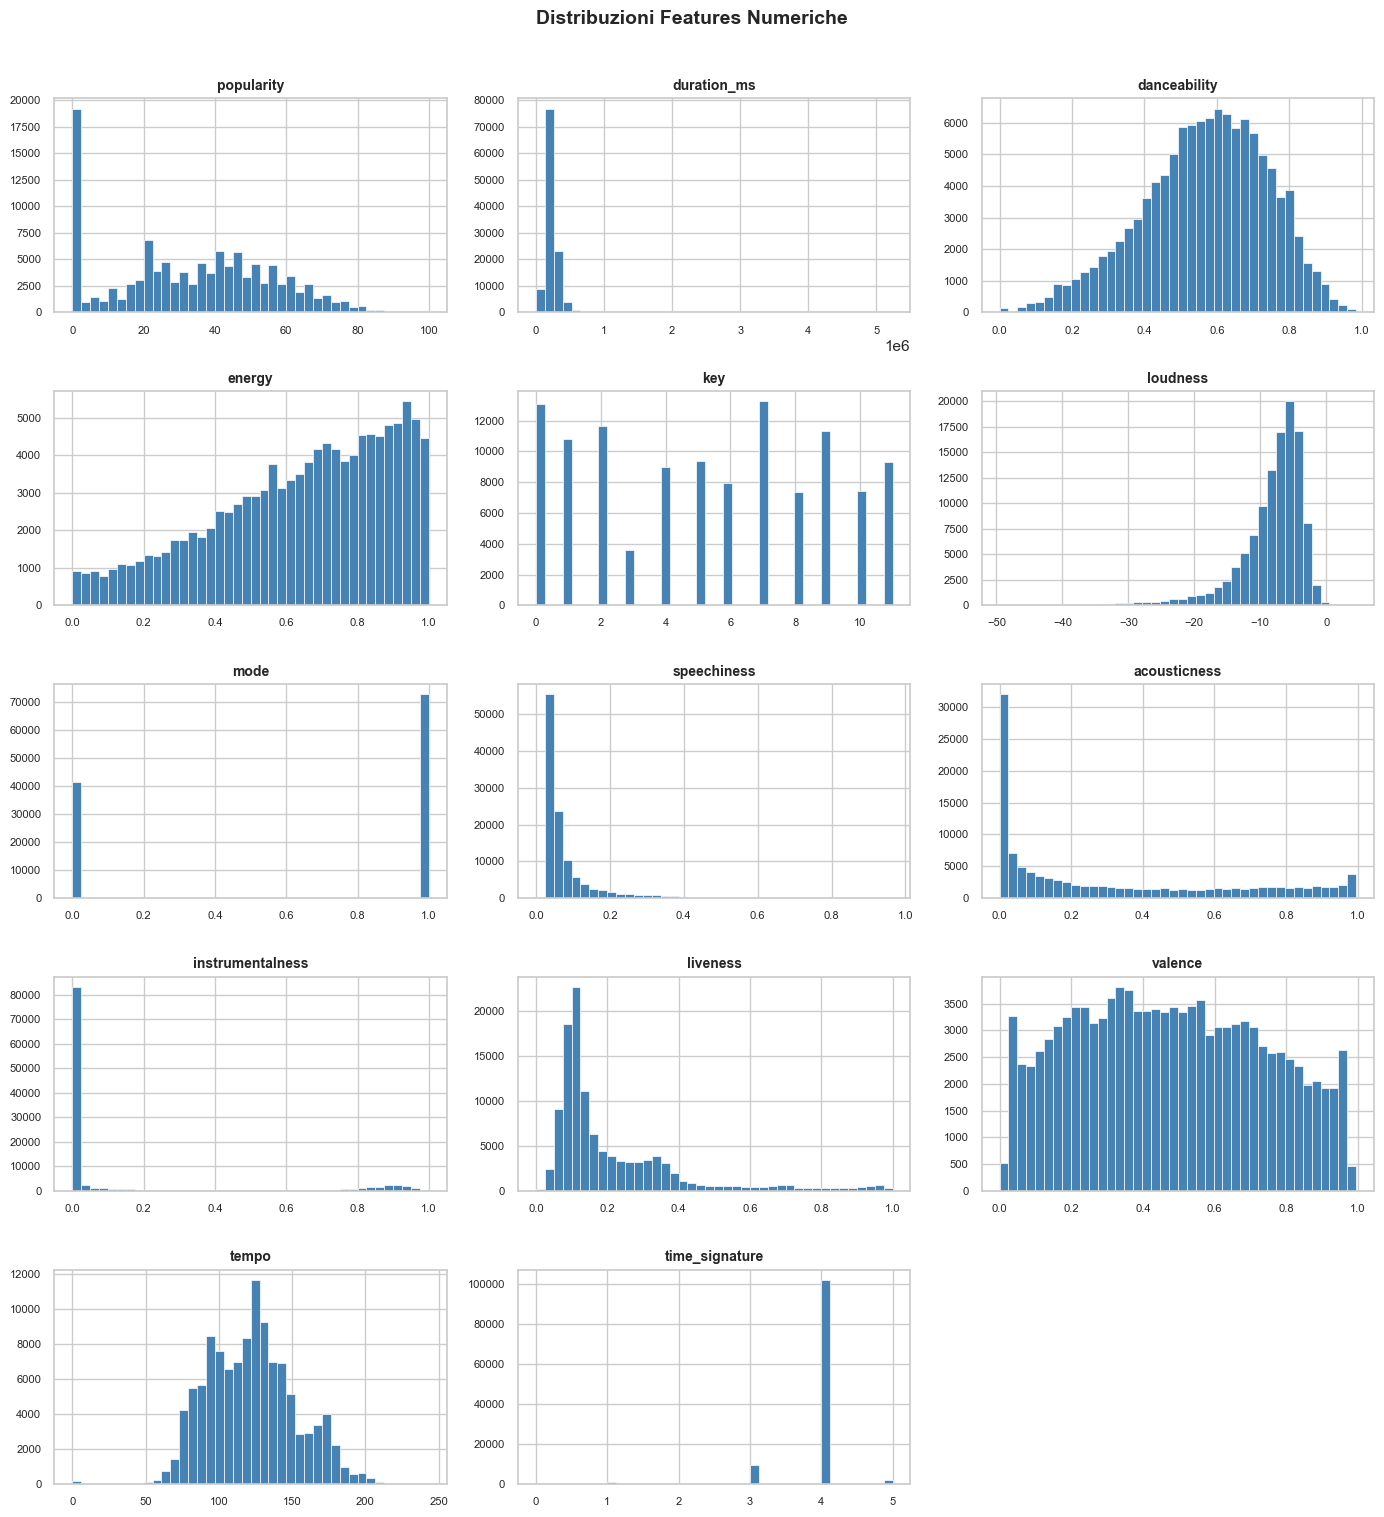

In [70]:
# Istogrammi per tutte le features numeriche
n = len(num_cols) # Numero di features numeriche
ncols = 3 # Numero di colonne per il layout
nrows = (n + ncols - 1) // ncols # Quante righe ci servono? Usiamo formula di arrotondamento per eccesso

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)

# Nascondi assi vuoti
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuzioni Features Numeriche', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Boxplot delle features numeriche

Gli istogrammi mostrano la distribuzione di ogni colonna singolarmente.
Il boxplot permette invece di **confrontarle tutte insieme** e individuare gli outlier.

### Il problema delle scale diverse

Le colonne numeriche hanno scale molto diverse — ad esempio `price` può andare 
da 0 a 3000, mentre `points` va da 80 a 100. Metterle sullo stesso grafico 
renderebbe alcune colonne illeggibili. Per questo normalizziamo i valori.

### Normalizzazione con MinMaxScaler
```python
from sklearn.preprocessing import MinMaxScaler

df_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(df[num_cols].dropna()),
    columns=num_cols
)
```

`MinMaxScaler` trasforma ogni colonna in un range **0–1**, dove:
- `0` = valore minimo della colonna
- `1` = valore massimo della colonna
```python
# Esempio
[4, 8, 12]  # → [0.0, 0.5, 1.0]
```

- `fit_transform()` — calcola il minimo e massimo e applica la trasformazione in un solo passaggio
- `dropna()` — rimuove i valori nulli prima della trasformazione, che non li accetta
- `pd.DataFrame(..., columns=num_cols)` — ricostruisce il DataFrame con i nomi delle colonne originali

### Come leggere un boxplot
```
        |
   ─────┼─────   ← outlier (punti oltre i baffi)
        │
   ┌────┴────┐
   │         │   ← 75° percentile (Q3)
   │─────────│   ← mediana
   │         │   ← 25° percentile (Q1)
   └────┬────┘
        │
   ─────┼─────   ← outlier
        |
```

- **La scatola** contiene il 50% centrale dei dati
- **La linea centrale** è la mediana
- **I baffi** si estendono fino a 1.5 volte la larghezza della scatola
- **I punti oltre i baffi** sono outlier

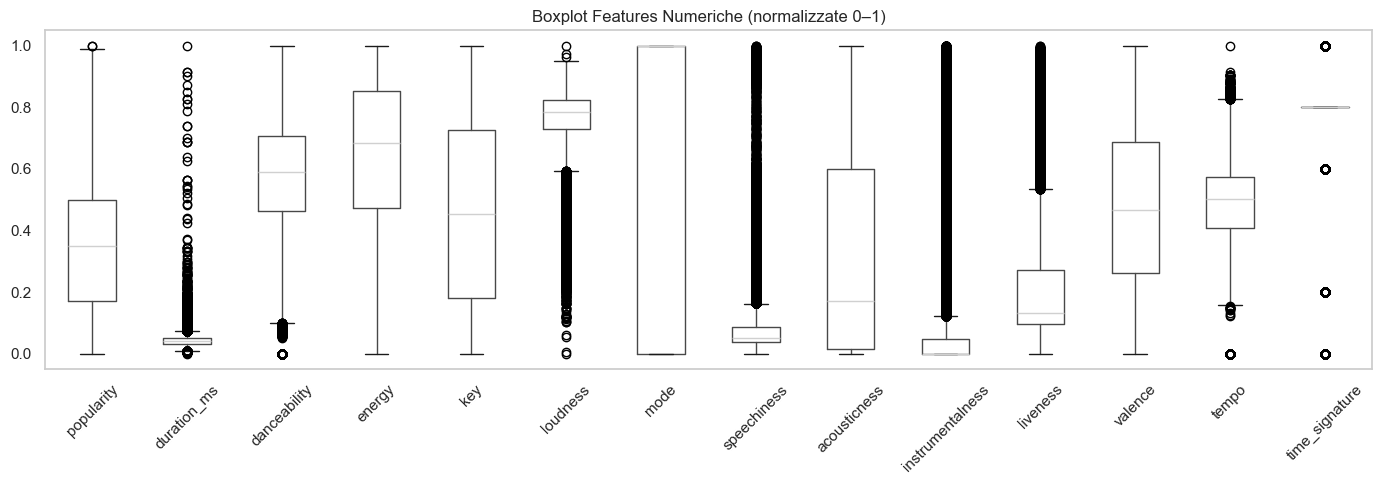

In [71]:
# Boxplot per confrontare scale e individuare outlier
# Normalizziamo per visualizzazione comparativa
from sklearn.preprocessing import MinMaxScaler

df_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(df[num_cols].dropna()),
    columns=num_cols
)

plt.figure(figsize=(14, 5))
df_scaled.boxplot(rot=45, grid=False)
plt.title('Boxplot Features Numeriche (normalizzate 0–1)')
plt.tight_layout()
plt.show()

---
## 5. Analisi Features Categoriche

In [72]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f'Colonne categoriche ({len(cat_cols)}): {cat_cols}')

Colonne categoriche (5): ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']


In [73]:
# Cardinalità (numero di valori unici) per ogni colonna categorica
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
print('Cardinalità colonne categoriche:')
display(cardinality.to_frame('n_unique'))

Cardinalità colonne categoriche:


,n_unique
track_id,89741
track_name,73608
album_name,46589
artists,31437
track_genre,114


In [75]:
# Bar chart top-10 valori per colonne con cardinalità bassa-media (≤ 50 valori unici)
low_card = [c for c in cat_cols if df[c].nunique() <= 50]

if low_card:
    n = len(low_card)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    
    for ax, col in zip(axes, low_card):
        counts = df[col].value_counts().head(10)
        counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(f'{col}\n(top 10)', fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print('Tutte le colonne categoriche hanno alta cardinalità (> 50 valori).')

Tutte le colonne categoriche hanno alta cardinalità (> 50 valori).


In [46]:
# Verifica duplicati esatti
n_dup = df.duplicated().sum()
print(f'Righe duplicate: {n_dup} ({n_dup / len(df) * 100:.2f}%)')

Righe duplicate: 0 (0.00%)


---
## 6. Analisi Correlazioni

## Matrice di correlazione

La correlazione misura quanto due variabili numeriche si muovono insieme.
Visualizzarla come heatmap permette di identificare rapidamente le relazioni
più forti nel dataset.

### Calcolare la matrice di correlazione
```python
corr_matrix = df[num_cols].corr()
```

Calcola la correlazione tra tutte le coppie di colonne numeriche.
Il risultato è una matrice simmetrica dove ogni cella contiene un valore tra -1 e 1:

- **1** → correlazione positiva perfetta (crescono insieme)
- **0** → nessuna correlazione lineare
- **-1** → correlazione negativa perfetta (una cresce, l'altra decresce)

### Mostrare solo il triangolo inferiore
```python
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
```

La matrice è simmetrica — la correlazione tra A e B è uguale a quella tra B e A.
Mostrare entrambi i triangoli sarebbe ridondante. `np.triu()` crea una maschera
booleana per nascondere il triangolo superiore e la diagonale.

### Parametri della heatmap
```python
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',   # mostra i valori con 2 decimali
    cmap='coolwarm',          # rosso = correlazione positiva, blu = negativa
    center=0,                 # centra la scala dei colori sullo 0
    vmin=-1, vmax=1           # forza la scala tra -1 e 1
)
```

---

## Indici di correlazione alternativi

Il metodo `.corr()` usa **Pearson** di default, ma non è sempre quello giusto:

### Pearson (default)
```python
df[num_cols].corr(method='pearson')
```
Misura la correlazione **lineare** tra due variabili continue.
Da usare quando i dati sono numerici continui e la relazione è lineare.
Sensibile agli outlier.

### Spearman
```python
df[num_cols].corr(method='spearman')
```
Misura la correlazione **monotonica** — se una variabile tende a crescere 
quando cresce l'altra, indipendentemente dalla linearità.
Da usare quando i dati hanno outlier o distribuzione non normale.
Più robusto di Pearson per dati reali.

### Kendall
```python
df[num_cols].corr(method='kendall')
```
Simile a Spearman ma basato su coppie ordinate.
Da usare con dataset piccoli o con molti valori ripetuti.

---

### Quale usare nel nostro caso?

Guardando gli istogrammi e i boxplot precedenti, il dataset Spotify ha:
- distribuzoni non gaussiane
- outlier significativi (duration_ms, loudness)

Per questo motivo **Spearman** è probabilmente più adatto di Pearson 
per catturare le relazioni reali tra le variabili.

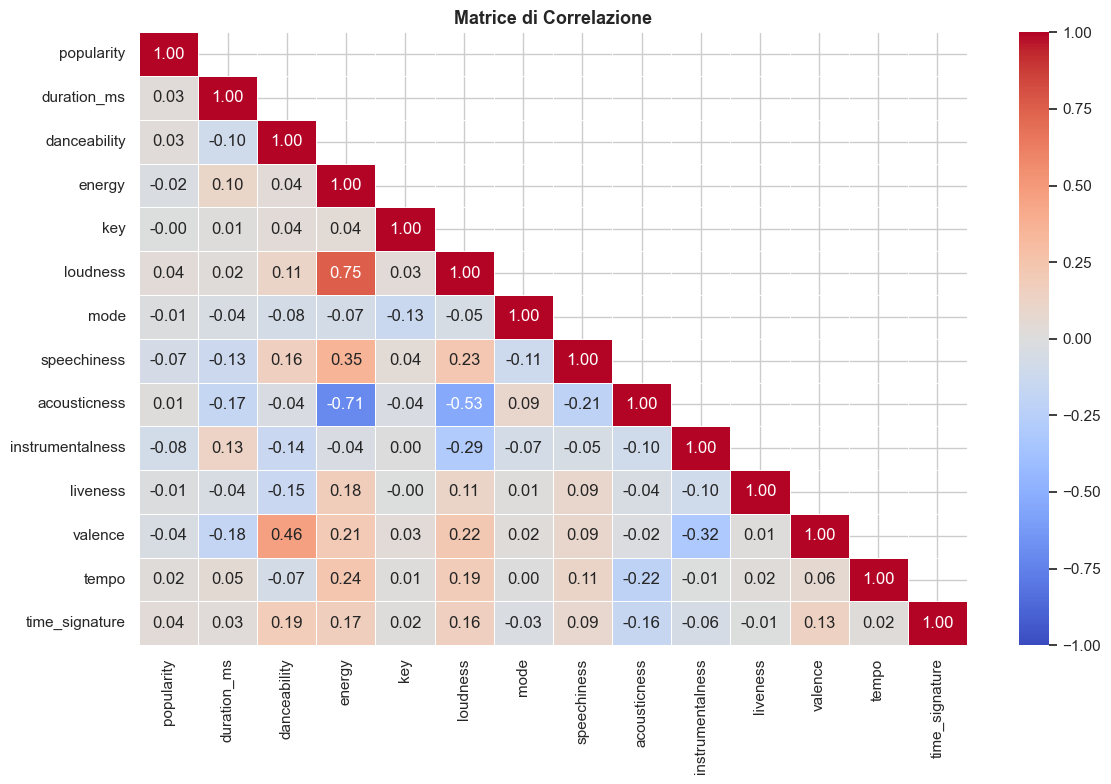

In [ ]:
# Matrice di correlazione: 

corr_matrix = df[num_cols].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Solo triangolo inferiore; k=1 esclude la diagonale dalla maschera

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    vmin=-1, vmax=1
)
plt.title('Matrice di Correlazione', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [79]:
# Top coppie più correlate (in valore assoluto)
corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['feature_1', 'feature_2', 'correlazione']
corr_pairs['abs_corr'] = corr_pairs['correlazione'].abs()
print('Top 10 coppie per correlazione assoluta:')
display(corr_pairs.sort_values('abs_corr', ascending=False).head(10).reset_index(drop=True))

Top 10 coppie per correlazione assoluta:


,feature_1,feature_2,correlazione,abs_corr
0,loudness,energy,0.750,0.750
1,acousticness,energy,-0.708,0.708
2,acousticness,loudness,-0.534,0.534
3,valence,danceability,0.462,0.462
4,speechiness,energy,0.355,0.355
5,valence,instrumentalness,-0.320,0.320
6,instrumentalness,loudness,-0.289,0.289
7,tempo,energy,0.241,0.241
8,speechiness,loudness,0.232,0.232
9,valence,loudness,0.221,0.221


---
## 7. Rilevamento Outlier (metodo IQR)

In [80]:
def detect_outliers_iqr(df, cols, k=1.5):
    """Restituisce un DataFrame con conteggio e percentuale di outlier per ogni colonna."""
    results = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - k * IQR, Q3 + k * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        results.append({'colonna': col, 'lower_bound': lower, 'upper_bound': upper,
                        'n_outliers': n_out, 'pct_outliers': n_out / len(df) * 100})
    return pd.DataFrame(results).sort_values('pct_outliers', ascending=False)

outlier_report = detect_outliers_iqr(df, num_cols)
display(outlier_report.style.bar(subset=['pct_outliers'], color='#f4a261').format({'pct_outliers': '{:.2f}%'}))

,colonna,lower_bound,upper_bound,n_outliers,pct_outliers
9,instrumentalness,-0.073500,0.122500,25246,22.15%
7,speechiness,-0.037000,0.157400,13211,11.59%
13,time_signature,4.000000,4.000000,12157,10.66%
10,liveness,-0.164500,0.535500,8642,7.58%
5,loudness,-17.528000,2.512000,6173,5.41%
1,duration_ms,42906.000000,392666.000000,5617,4.93%
2,danceability,0.097500,1.053500,620,0.54%
12,tempo,37.940375,201.349375,617,0.54%
0,popularity,-32.500000,99.500000,2,0.00%
3,energy,-0.101000,1.427000,0,0.00%


---
## 8. Preprocessing

In [81]:
df_clean = df.copy()
print(f'Shape iniziale: {df_clean.shape}')

Shape iniziale: (114000, 20)


### 8.1 Rimozione duplicati

In [82]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f'Duplicati rimossi: {before - after} righe  →  Shape: {df_clean.shape}')

Duplicati rimossi: 450 righe  →  Shape: (113550, 20)


### 8.2 Gestione valori mancanti

In [83]:
# Numeriche → imputa con mediana (robusta agli outlier)
# Categoriche → imputa con moda

for col in df_clean.select_dtypes(include='number').columns:
    n_miss = df_clean[col].isnull().sum()
    if n_miss > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f'  [NUM] {col}: {n_miss} valori imputati con mediana ({median_val:.3f})')

for col in df_clean.select_dtypes(include=['object', 'string']).columns:
    n_miss = df_clean[col].isnull().sum()
    if n_miss > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f'  [CAT] {col}: {n_miss} valori imputati con moda ("{mode_val}")')

print(f'\nValori mancanti residui: {df_clean.isnull().sum().sum()}')

  [CAT] artists: 1 valori imputati con moda ("The Beatles")
  [CAT] album_name: 1 valori imputati con moda ("Alternative Christmas 2022")
  [CAT] track_name: 1 valori imputati con moda ("Run Rudolph Run")

Valori mancanti residui: 0


### 8.3 Feature engineering: durata in minuti

## Feature Engineering — trasformare le colonne esistenti

Il **feature engineering** consiste nel creare nuove colonne a partire da quelle 
esistenti per rendere i dati più interpretabili o utili per l'analisi.

### Convertire la durata in minuti

`duration_ms` esprime la durata in millisecondi — un'unità poco intuitiva.
Convertiamo in minuti dividendo per 60.000 (1 minuto = 60.000 ms).
```python
df_clean['duration_min'] = df_clean['duration_ms'] / 60_000
```

Il numero `60_000` è identico a `60000` — Python permette di usare `_` come 
separatore visivo nelle cifre per rendere i numeri grandi più leggibili.

### Controllo preventivo con if
```python
if 'duration_ms' in df_clean.columns:
    ...
else:
    print('Colonna duration_ms non trovata — step saltato')
```

Prima di trasformare la colonna verifichiamo che esista nel DataFrame.
È una buona pratica per rendere il codice **robusto** — se il dataset cambia 
o la colonna viene rimossa in un passaggio precedente, il codice non va in errore
ma stampa un messaggio informativo e continua.

In [85]:
# Se esiste una colonna 'duration_ms', convertiamo in minuti
if 'duration_ms' in df_clean.columns:
    df_clean['duration_min'] = df_clean['duration_ms'] / 60_000
    print('Aggiunta colonna duration_min')
    print(df_clean['duration_min'].describe())
else:
    print('Colonna duration_ms non trovata — step saltato')

Aggiunta colonna duration_min
count   113550.000
mean         3.801
std          1.774
min          0.000
25%          2.903
50%          3.550
75%          4.360
max         87.288
Name: duration_min, dtype: float64


### 8.4 Encoding variabili categoriche

## Encoding delle variabili categoriche

I modelli di machine learning lavorano solo con numeri — le colonne testuali 
come `genre` o `artist` devono essere convertite in valori numerici. 
Questo processo si chiama **encoding**.

### I due tipi di encoding

#### One-Hot Encoding (OHE)
Per colonne con **poche categorie** (bassa cardinalità).
Crea una nuova colonna binaria (0/1) per ogni categoria.
```
genre                        genre_pop  genre_rock  genre_jazz
─────────────────────────    ──────────────────────────────────
pop          →               1          0           0
rock         →               0          1           0
jazz         →               0          0           1
```
```python
pd.get_dummies(df_clean[col], prefix=col, drop_first=True, dtype=int)
```
- `prefix=col` — aggiunge il nome della colonna originale come prefisso
- `drop_first=True` — elimina la prima categoria per evitare ridondanza 
  (se non è `pop` né `rock`, è necessariamente `jazz`)
- `dtype=int` — usa 0 e 1 invece di True/False

#### Label Encoding (LE)
Per colonne con **molte categorie** (alta cardinalità).
Assegna un numero intero ad ogni categoria.
```
artist                       artist_enc
──────────────────────────   ──────────
"Taylor Swift"   →           0
"Drake"          →           1
"Bad Bunny"      →           2
```
```python
le = LabelEncoder()
df_clean[col + '_enc'] = le.fit_transform(df_clean[col].astype(str))
```

*Attenzione!* Il Label Encoding introduce un ordine implicito (0 < 1 < 2) che non esiste 
realmente tra gli artisti — per questo si usa solo per colonne ad alta cardinalità 
dove l'OHE creerebbe troppe colonne.

### La soglia di cardinalità
```python
LOW_CARD_THRESHOLD = 15
```

Se una colonna ha **15 o meno** categorie uniche → OHE  
Se ne ha **più di 15** → Label Encoding

Questa soglia è arbitraria e può essere modificata in base al dataset.

### Salvare gli encoder
```python
encoders[col] = le
```

Gli encoder vengono salvati in un dizionario per poterli riutilizzare in seguito —
ad esempio per decodificare le predizioni del modello o per trasformare nuovi dati.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Colonne categoriche con bassa cardinalità: One-Hot Encoding
# Colonne ad alta cardinalità → Label Encoding (es. artisti, tracce)

LOW_CARD_THRESHOLD = 15
encoders = {}

print(f"Colonne categoriche trovate: {cat_cols}")

for col in cat_cols:
    if col not in df_clean.columns:
        continue
    n_unique = df_clean[col].nunique()
    
    if n_unique <= LOW_CARD_THRESHOLD:
        # One-Hot Encoding
        dummies = pd.get_dummies(df_clean[col], prefix=col, drop_first=True, dtype=int)
        df_clean = pd.concat([df_clean.drop(columns=[col]), dummies], axis=1)
        print(f'  [OHE] {col}  ({n_unique} categorie → {len(dummies.columns)} dummy)')
    else:
        # Label Encoding
        le = LabelEncoder()
        df_clean[col + '_enc'] = le.fit_transform(df_clean[col].astype(str))
        df_clean = df_clean.drop(columns=[col])
        encoders[col] = le
        print(f'  [LE]  {col}  ({n_unique} valori unici → colonna {col}_enc)')

print(f'\nShape dopo encoding: {df_clean.shape}')
print(df_clean.shape)
display(df_clean.head())

Colonne categoriche trovate: ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']
Colonne in df_clean: ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'duration_min', 'track_id_enc', 'artists_enc', 'album_name_enc', 'track_name_enc', 'track_genre_enc']

Shape dopo encoding: (113550, 21)
(113550, 21)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min,track_id_enc,artists_enc,album_name_enc,track_name_enc,track_genre_enc
0,1.780,0.024,False,0.628,-0.721,-1.210,0.299,0,0.551,-0.849,-0.504,0.758,0.929,-1.143,0.222,0.024,0.694,-0.593,-1.074,-1.180,-1.717
1,0.973,-0.737,False,-0.848,-1.896,-1.210,-1.794,1,-0.079,1.838,-0.504,-0.591,-0.799,-1.491,0.222,-0.737,0.417,-1.372,-0.576,-0.664,-1.717
2,1.062,-0.162,False,-0.744,-1.128,-1.491,-0.297,1,-0.274,-0.314,-0.504,-0.507,-1.367,-1.530,0.222,-0.162,-0.968,-0.369,1.237,1.163,-1.717
3,1.691,-0.246,False,-1.736,-2.320,-1.491,-2.050,1,-0.457,1.780,-0.503,-0.428,-1.278,1.987,-2.093,-0.246,1.276,-0.100,-1.038,-1.283,-1.717
4,2.184,-0.275,False,0.294,-0.793,-0.930,-0.287,1,-0.303,0.467,-0.504,-0.686,-1.185,-0.074,0.222,-0.275,0.902,-1.156,-0.420,-0.513,-1.717


In [99]:
print('=== RIEPILOGO PREPROCESSING ===')
print(f'  Shape originale  : {df.shape}')
print(f'  Shape finale     : {df_clean.shape}')
print(f'  Valori mancanti  : {df_clean.isnull().sum().sum()}')
print(f'  Tipi colonne     : {dict(df_clean.dtypes.value_counts())}')

df_clean.head()

=== RIEPILOGO PREPROCESSING ===
  Shape originale  : (114000, 20)
  Shape finale     : (113550, 21)
  Valori mancanti  : 0
  Tipi colonne     : {dtype('float64'): np.int64(19), dtype('bool'): np.int64(1), dtype('int64'): np.int64(1)}


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min,track_id_enc,artists_enc,album_name_enc,track_name_enc,track_genre_enc
0,1.780,0.024,False,0.628,-0.721,-1.210,0.299,0,0.551,-0.849,-0.504,0.758,0.929,-1.143,0.222,0.024,0.694,-0.593,-1.074,-1.180,-1.717
1,0.973,-0.737,False,-0.848,-1.896,-1.210,-1.794,1,-0.079,1.838,-0.504,-0.591,-0.799,-1.491,0.222,-0.737,0.417,-1.372,-0.576,-0.664,-1.717
2,1.062,-0.162,False,-0.744,-1.128,-1.491,-0.297,1,-0.274,-0.314,-0.504,-0.507,-1.367,-1.530,0.222,-0.162,-0.968,-0.369,1.237,1.163,-1.717
3,1.691,-0.246,False,-1.736,-2.320,-1.491,-2.050,1,-0.457,1.780,-0.503,-0.428,-1.278,1.987,-2.093,-0.246,1.276,-0.100,-1.038,-1.283,-1.717
4,2.184,-0.275,False,0.294,-0.793,-0.930,-0.287,1,-0.303,0.467,-0.504,-0.686,-1.185,-0.074,0.222,-0.275,0.902,-1.156,-0.420,-0.513,-1.717


In [98]:
# Salvataggio dataset preprocessato
output_path = os.path.join(os.getcwd(), "data", "spotify_preprocessed.csv")
df_clean.to_csv(output_path, index=False)
print(f'Dataset salvato in: {output_path}')

Dataset salvato in: /Users/gcoucourde/Desktop/solutions/lezione3/data/spotify_preprocessed.csv
